In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
file_path = '/content/Amazon - Amazon.csv.csv'
df = pd.read_csv(file_path)

In [18]:
print(df.head())

      OrderID   OrderDate  CustomerID   CustomerName ProductID  \
0  ORD0000001  2023-01-31  CUST001504  Vihaan Sharma    P00014   
1  ORD0000002  2023-12-30  CUST000178    Pooja Kumar    P00040   
2  ORD0000003  2022-05-10  CUST047516    Sneha Singh    P00044   
3  ORD0000004  2023-07-18  CUST030059   Vihaan Reddy    P00041   
4  ORD0000005  2023-02-04  CUST048677  Aditya Kapoor    P00029   

           ProductName        Category       Brand  Quantity UnitPrice  \
0           Drone Mini           Books   BrightLux         3    106,59   
1           Microphone  Home & Kitchen  UrbanStyle         1    251,37   
2  Power Bank 20000mAh        Clothing  UrbanStyle         3     35,03   
3       Webcam Full HD  Home & Kitchen      Zenith         5     33,58   
4              T-Shirt        Clothing    KiddoFun         2    515,64   

  Discount    Tax ShippingCost TotalAmount     PaymentMethod OrderStatus  \
0     0,00   0,00         0,09      319,86        Debit Card   Delivered   
1     

In [19]:
#Jumlah baris  dan kolom
print(df.shape)

(100000, 20)


In [20]:
#Informasi dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   OrderID        100000 non-null  object
 1   OrderDate      100000 non-null  object
 2   CustomerID     100000 non-null  object
 3   CustomerName   100000 non-null  object
 4   ProductID      100000 non-null  object
 5   ProductName    100000 non-null  object
 6   Category       100000 non-null  object
 7   Brand          100000 non-null  object
 8   Quantity       100000 non-null  int64 
 9   UnitPrice      100000 non-null  object
 10  Discount       100000 non-null  object
 11  Tax            100000 non-null  object
 12  ShippingCost   100000 non-null  object
 13  TotalAmount    100000 non-null  object
 14  PaymentMethod  100000 non-null  object
 15  OrderStatus    100000 non-null  object
 16  City           100000 non-null  object
 17  State          100000 non-null  object
 18  Count

In [21]:
#Statistik deskriptif
print(df.describe())

            Quantity
count  100000.000000
mean        3.001400
std         1.413548
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000


In [27]:
cols = ['UnitPrice','Discount','Tax','ShippingCost','TotalAmount']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [28]:
# Mengubah OrderDate menjadi format datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [29]:
print(df.isnull().sum())

OrderID              0
OrderDate            0
CustomerID           0
CustomerName         0
ProductID            0
ProductName          0
Category             0
Brand                0
Quantity             0
UnitPrice            0
Discount             0
Tax                  0
ShippingCost         0
TotalAmount      37644
PaymentMethod        0
OrderStatus          0
City                 0
State                0
Country              0
SellerID             0
dtype: int64


In [30]:
# Total penjualan keseluruhan
total_sales = df['TotalAmount'].sum()
print('Total Sales :', total_sales)

Total Sales : 27824452.51


In [31]:
category_sales = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

print(category_sales)

Category
Sports & Outdoors    4717850.09
Books                4683520.17
Home & Kitchen       4652880.68
Electronics          4611694.99
Toys & Games         4595287.64
Clothing             4563218.94
Name: TotalAmount, dtype: float64


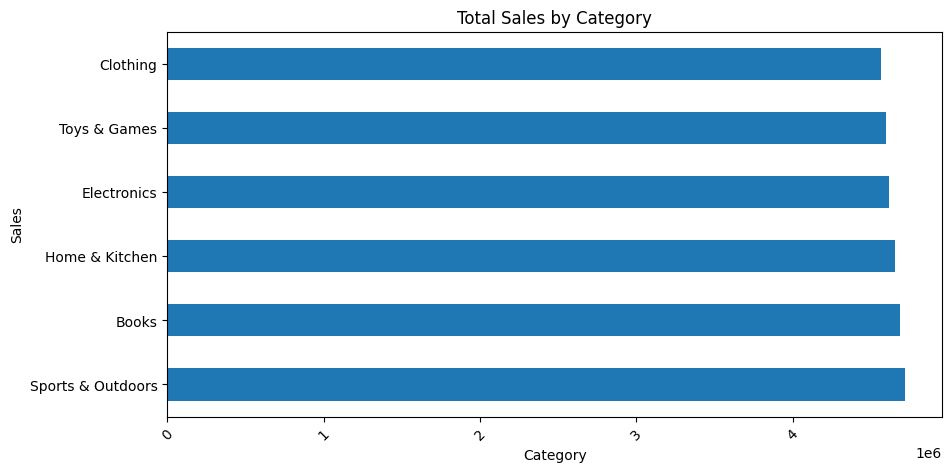

In [38]:
category_sales.plot(kind='barh', figsize=(10,5))
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [61]:
#Produk Terlaris
best_product = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)

print(best_product)

ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64


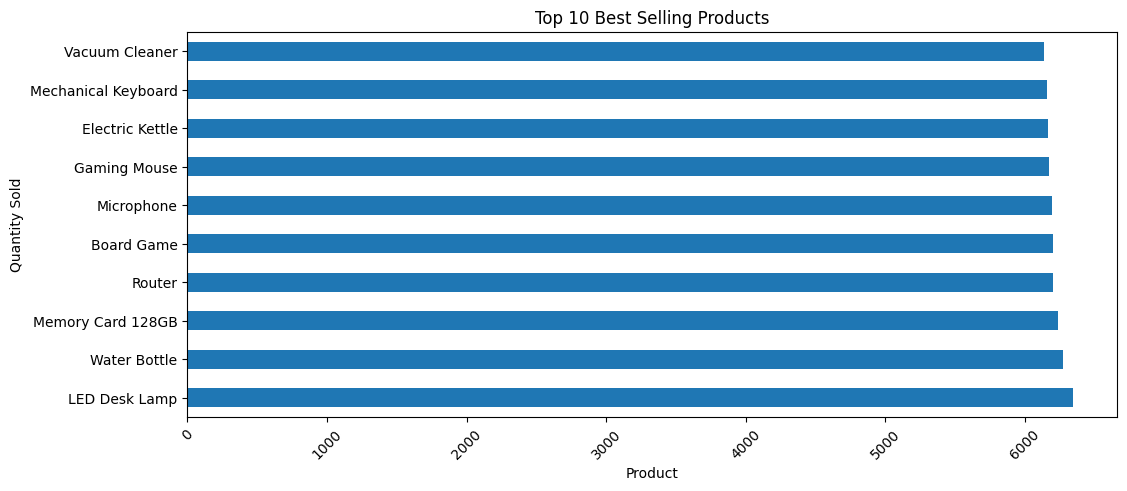

In [62]:
best_product.plot(kind='barh', figsize=(12,5))
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

In [39]:
#Penjualan Berdasarkan Negara
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

print(country_sales)

Country
United States     19561096.58
India              4149001.34
Canada             1605289.67
United Kingdom     1356677.17
Australia          1152387.75
Name: TotalAmount, dtype: float64


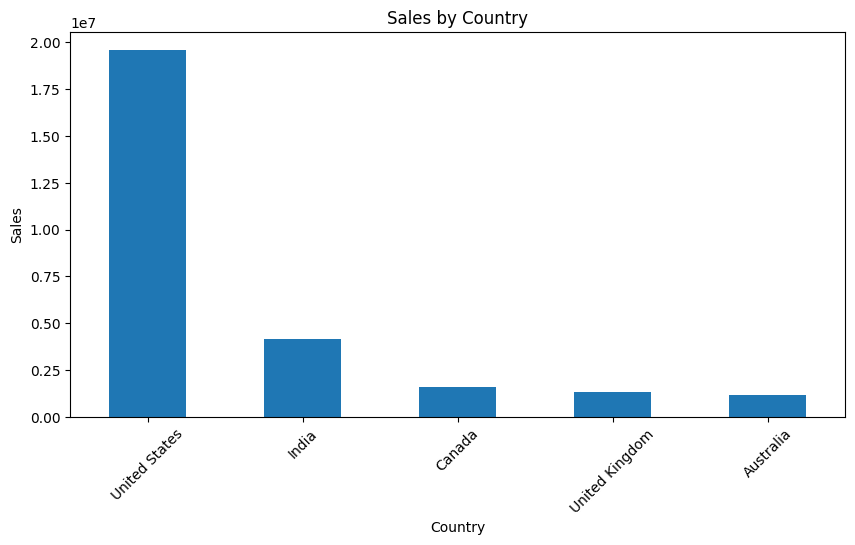

In [40]:
country_sales.plot(kind='bar', figsize=(10,5))
plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [41]:
#Status Pesanan
order_status = df['OrderStatus'].value_counts()

print(order_status)

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64


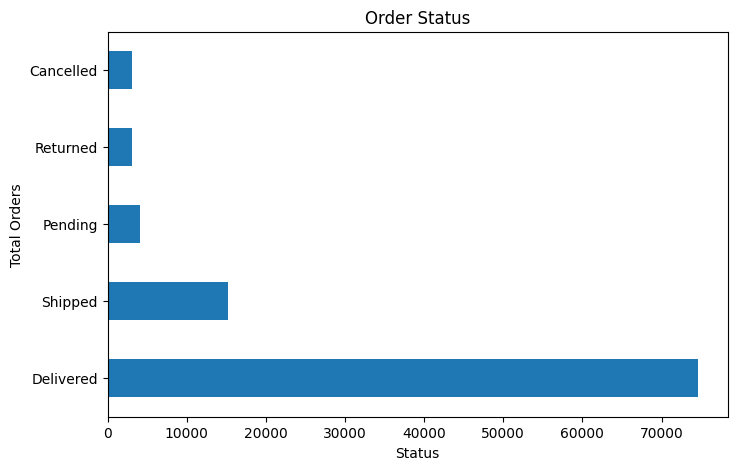

In [43]:
order_status.plot(kind='barh', figsize=(8,5))
plt.title('Order Status')
plt.xlabel('Status')
plt.ylabel('Total Orders')
plt.show()

In [49]:
#Penjualan Per Bulan
df['Years'] = df['OrderDate'].dt.to_period('Y')

monthly_sales = df.groupby('Years')['TotalAmount'].sum()

print(monthly_sales)

Years
2020    5579258.99
2021    5534130.44
2022    5576126.45
2023    5591502.84
2024    5543433.79
Freq: Y-DEC, Name: TotalAmount, dtype: float64


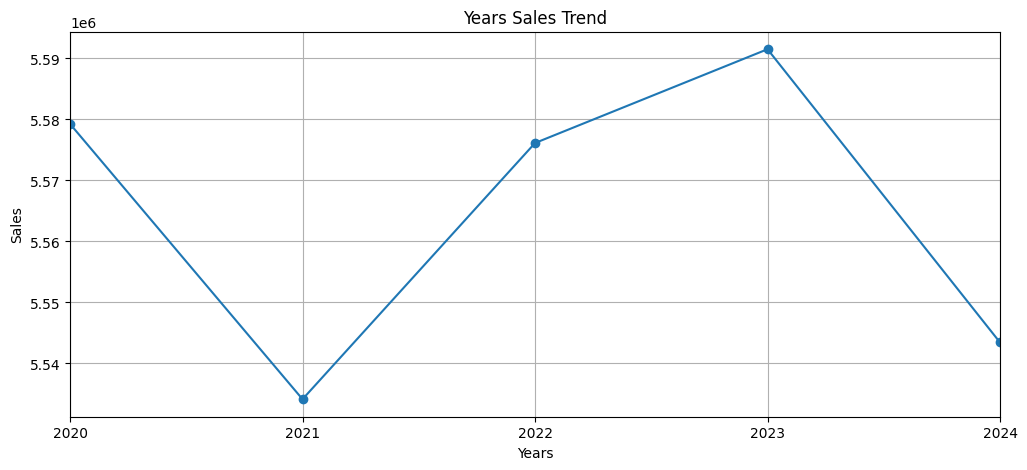

In [50]:
monthly_sales.plot(figsize=(12,5), marker='o')
plt.title('Years Sales Trend')
plt.xlabel('Years')
plt.ylabel('Sales')
plt.grid(True)
plt.show()